<a href="https://colab.research.google.com/github/Aadi-cpu6/Trader-Performance-vs-Market-Sentiment/blob/main/Trading_Behavior_vs_Market_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
fear = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

fear.head()
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2/12/2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2/12/2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2/12/2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2/12/2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2/12/2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
fear['date'] = pd.to_datetime(fear['date'])
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])

# Normalize to same format
fear['date'] = fear['date'].dt.normalize()
trades['date'] = trades['Timestamp'].dt.normalize()

In [ ]:
merged = pd.merge(
    trades,
    fear[['date', 'value', 'classification']],
    on='date',
    how='left'
)
display(merged.head())

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2/12/2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,NaT,NaT,NaN,NaN
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2/12/2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,NaT,NaT,NaN,NaN
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2/12/2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,NaT,NaT,NaN,NaN
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2/12/2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,NaT,NaT,NaN,NaN
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2/12/2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,NaT,NaT,NaN,NaN


In [ ]:
merged['win'] = merged['Closed PnL'] > 0
merged['trade_size_usd'] = merged['Size USD']
merged['long_trade'] = merged['Side'].astype(str).str.upper().str.contains('BUY')
display(merged.head())

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Crossed,Fee,Trade ID,Timestamp,date,value,classification,win,trade_size_usd,long_trade
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2/12/2024 22:50,0.000000,Buy,0.0,...,True,0.345404,8.950000e+14,1970-01-01 00:28:50,1970-01-01,NaN,NaN,False,7872.16,True
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2/12/2024 22:50,986.524596,Buy,0.0,...,True,0.005600,4.430000e+14,1970-01-01 00:28:50,1970-01-01,NaN,NaN,False,127.68,True
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2/12/2024 22:50,1002.518996,Buy,0.0,...,True,0.050431,6.600000e+14,1970-01-01 00:28:50,1970-01-01,NaN,NaN,False,1150.63,True
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2/12/2024 22:50,1146.558564,Buy,0.0,...,True,0.050043,1.080000e+15,1970-01-01 00:28:50,1970-01-01,NaN,NaN,False,1142.04,True
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2/12/2024 22:50,1289.488521,Buy,0.0,...,True,0.003055,1.050000e+15,1970-01-01 00:28:50,1970-01-01,NaN,NaN,False,69.75,True


In [ ]:
daily_metrics = merged.groupby(['date', 'classification']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trades=('Closed PnL', 'count'),
    win_rate=('win', 'mean'),
    avg_trade_size=('trade_size_usd', 'mean'),
    long_ratio=('long_trade', 'mean')
).reset_index()
display(daily_metrics.head())

,date,classification,daily_pnl,trades,win_rate,avg_trade_size,long_ratio


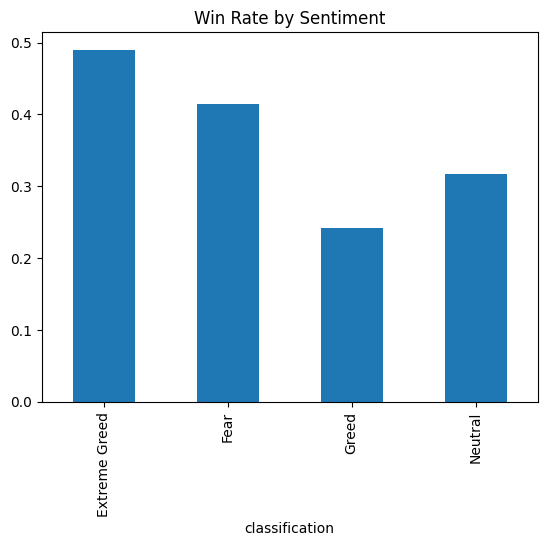

In [ ]:
#Win rate by sentiment
plt.figure()
daily_metrics.groupby('classification')['win_rate'].mean().plot(kind='bar')
plt.title('Win Rate by Sentiment')
plt.show()

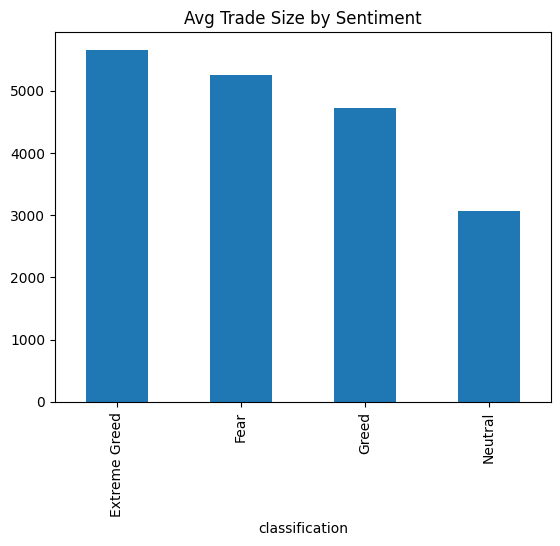

In [ ]:
#Trade size by Sentiment
plt.figure()
daily_metrics.groupby('classification')['avg_trade_size'].mean().plot(kind='bar')
plt.title('Avg Trade Size by Sentiment')
plt.show()

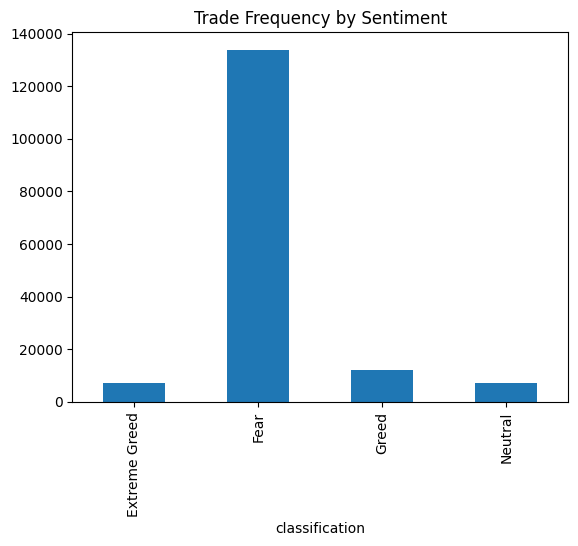

In [ ]:
plt.figure()
daily_metrics.groupby('classification')['trades'].mean().plot(kind='bar')
plt.title('Trade Frequency by Sentiment')
plt.show()

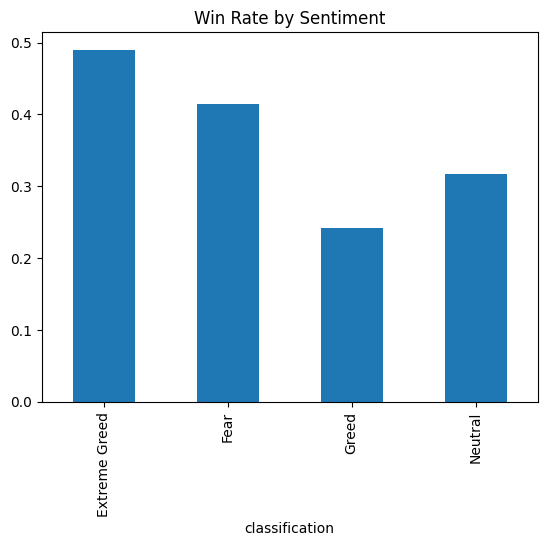

In [ ]:
plt.figure()
daily_metrics.groupby('classification')['win_rate'].mean().plot(kind='bar')
plt.title('Win Rate by Sentiment')
plt.show()

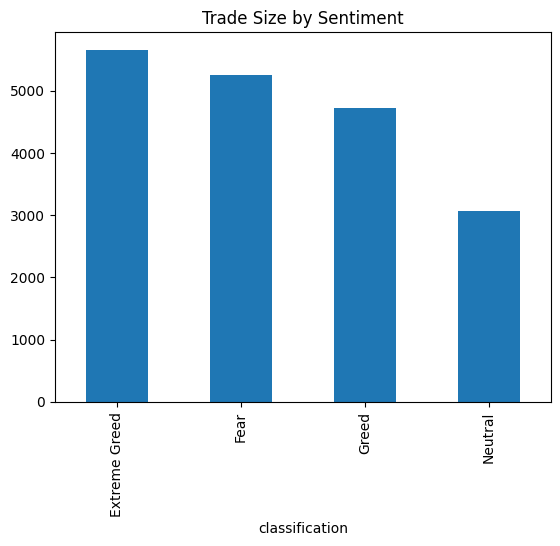

In [ ]:
plt.figure()
daily_metrics.groupby('classification')['avg_trade_size'].mean().plot(kind='bar')
plt.title('Trade Size by Sentiment')
plt.show()

In [ ]:
trader_activity = merged.groupby('Account').agg(
    total_trades=('Closed PnL', 'count'),
    total_pnl=('Closed PnL', 'sum')
).reset_index()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
daily_metrics.to_csv("processed_trading_sentiment.csv", index=False)